In [228]:
from qdrant_client import QdrantClient
from qdrant_client.http.models import Filter, FieldCondition, MatchValue
from qdrant_client.models import Distance, VectorParams, PointStruct
from tqdm import tqdm

from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from scipy.sparse import csgraph
from sklearn.manifold import SpectralEmbedding
from sklearn.preprocessing import normalize

import numpy as np
import torch
from PIL import Image
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

from pathlib import Path
import re

#importing the used models
from transformers import AutoTokenizer, CLIPModel, AutoProcessor, CLIPConfig, CLIPTokenizer, CLIPProcessor

from utils.metrics import iterate_ds, mean_reciprocal_rank, recall_at_k
from spectral_code import compute_spectral_embedding

# Step 1: Read in Short generated captions CSV with image paths installed locally

In [229]:
df_s_captions = pd.read_csv("./short_generated_captions.csv")

In [230]:
df_s_captions.head()

,id,img_url,original_caption,paraphrased_caption
0,1,https://thumbs.dreamstime.com/b/car-riding-wet...,Car riding on wet street. Car driving on wet c...,Vehicle driving on a rainy city street.
1,2,https://images.pexels.com/photos/770224/pexels...,Water Coming Out Of A Pipe,Water spilling from a pipe.
2,3,https://filmfare.wwmindia.com/content/2017/jul...,MARCH 2009 ''It's sad that a boy and girl can ...,MARCH 2009 'It's unfortunate that a boy and gi...
3,4,https://southernersays.com/wp-content/uploads/...,Humpback Whale tail in the Bay of Banderas,Humpback whale fin in the Banderas Bay.
4,5,https://i.pinimg.com/originals/9a/f5/a6/9af5a6...,"The gaming Team logo of team DUO Team Logo, My...",DUO Team logo design featuring gaming themes.


In [231]:
len(df_s_captions)

499

## Retrieve each image path using ids column

In [232]:
ids = df_s_captions["id"]

In [233]:
ids

0        1
1        2
2        3
3        4
4        5
      ... 
494    495
495    496
496    497
497    498
498    499
Name: id, Length: 499, dtype: int64

Now, we use these ids to search for images to get all relevant images for each path. The format of image paths is `img_{id}`

In [234]:
valid_img_paths = [f'./images/img_{id}.jpg' for id in ids]

In [235]:
valid_img_paths

['./images/img_1.jpg',
 './images/img_2.jpg',
 './images/img_3.jpg',
 './images/img_4.jpg',
 './images/img_5.jpg',
 './images/img_6.jpg',
 './images/img_7.jpg',
 './images/img_8.jpg',
 './images/img_9.jpg',
 './images/img_10.jpg',
 './images/img_11.jpg',
 './images/img_12.jpg',
 './images/img_13.jpg',
 './images/img_14.jpg',
 './images/img_15.jpg',
 './images/img_16.jpg',
 './images/img_17.jpg',
 './images/img_18.jpg',
 './images/img_19.jpg',
 './images/img_20.jpg',
 './images/img_21.jpg',
 './images/img_22.jpg',
 './images/img_23.jpg',
 './images/img_24.jpg',
 './images/img_25.jpg',
 './images/img_26.jpg',
 './images/img_27.jpg',
 './images/img_28.jpg',
 './images/img_29.jpg',
 './images/img_30.jpg',
 './images/img_31.jpg',
 './images/img_32.jpg',
 './images/img_33.jpg',
 './images/img_34.jpg',
 './images/img_35.jpg',
 './images/img_36.jpg',
 './images/img_37.jpg',
 './images/img_38.jpg',
 './images/img_39.jpg',
 './images/img_40.jpg',
 './images/img_41.jpg',
 './images/img_42.jpg',
 

# Step 2: Load in models and vector database, and convert image and text to embeddings

In [236]:
# Load in Qdrant client
client = QdrantClient(url="http://localhost:6333")
collection_name = "image_db"

In [237]:
# Load in the model to be used
device = "cuda" if torch.cuda.is_available() else "cpu"

# model_id = ("openai/clip-vit-base-patch32")
# config = CLIPConfig.from_pretrained(model_id)
# config.text_config.max_position_embeddings = 248

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
# tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32", config=config)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

In [238]:
embeddings = []
for path in valid_img_paths:
    try:
        image = Image.open(path).convert("RGB")
        inputs = processor(images=image, return_tensors="pt")
        with torch.no_grad():
            features = model.get_image_features(**inputs)
        # features = features / features.norm(p=2, dim=-1, keepdim=True)
        embeddings.append(features.cpu().numpy().squeeze())
    except Exception as e:
        print(f"Error processing image {path}: {e}")

# Step 3: Load the embeddings into Qdrant

In [239]:
collection_name = "image_db"

client = QdrantClient(host="localhost", port=6333)
points = [
    PointStruct(id=idx, vector=vec, payload={})
    for idx, vec in zip(ids, embeddings)
]

client.upsert(collection_name=collection_name, points=points)

UpdateResult(operation_id=0, status=<UpdateStatus.COMPLETED: 'completed'>)

# Step 4: Recording Metrics

In [240]:
df_s_captions[:10]

,id,img_url,original_caption,paraphrased_caption
0,1,https://thumbs.dreamstime.com/b/car-riding-wet...,Car riding on wet street. Car driving on wet c...,Vehicle driving on a rainy city street.
1,2,https://images.pexels.com/photos/770224/pexels...,Water Coming Out Of A Pipe,Water spilling from a pipe.
2,3,https://filmfare.wwmindia.com/content/2017/jul...,MARCH 2009 ''It's sad that a boy and girl can ...,MARCH 2009 'It's unfortunate that a boy and gi...
3,4,https://southernersays.com/wp-content/uploads/...,Humpback Whale tail in the Bay of Banderas,Humpback whale fin in the Banderas Bay.
4,5,https://i.pinimg.com/originals/9a/f5/a6/9af5a6...,"The gaming Team logo of team DUO Team Logo, My...",DUO Team logo design featuring gaming themes.
5,6,https://themaydan.com/wp-content/uploads/2019/...,"Tea, chilies, and takeaway: what food choices ...","Tea, chilies, and takeout: insights into Briti..."
6,7,https://i.pinimg.com/originals/ae/f4/f3/aef4f3...,The Bath Co. Camberley satin grey vanity unit ...,The Bath Co. Camberley satin grey vanity unit ...
7,8,https://photogallery.indiatimes.com/photo/6551...,Celebs attend the launch of a style store,Celebrities grace the opening of a fashion store.
8,9,https://images.squarespace-cdn.com/content/v1/...,Europe always amazes me on how well their arch...,I'm always impressed by how Europe's architect...
9,10,https://slideplayer.com/slide/13821916/85/imag...,The Development of the Court,The Evolution of the Court


In [241]:
avg_mrr = iterate_ds(10, df_s_captions, "mrr", processor, model, "original_caption", client, collection_name, device)
print(avg_mrr)

0.8386018067881796


In [242]:
avg_recall_at_5 = iterate_ds(5, df_s_captions, "recall@k", processor, model, "original_caption", client, collection_name, device)
print(avg_recall_at_5)

0.9118236472945892


In [243]:
avg_recall_at_10 = iterate_ds(10, df_s_captions, "recall@k", processor, model, "original_caption", client, collection_name, device)
print(avg_recall_at_10)

0.9438877755511023


# Step 5: Visualise Results

In [244]:
# to visualise results, we need to plot the distances between embeddings. We thus need to calculate textual embeddings

og_captions =[i for i in df_s_captions["original_caption"]]
inputs = processor(text=og_captions, return_tensors="pt", padding=True, truncation=True)

# convert into a dictionary to tell to pass intput to device
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    text_embeddings = model.get_text_features(**inputs)

In [245]:
len(text_embeddings)

499

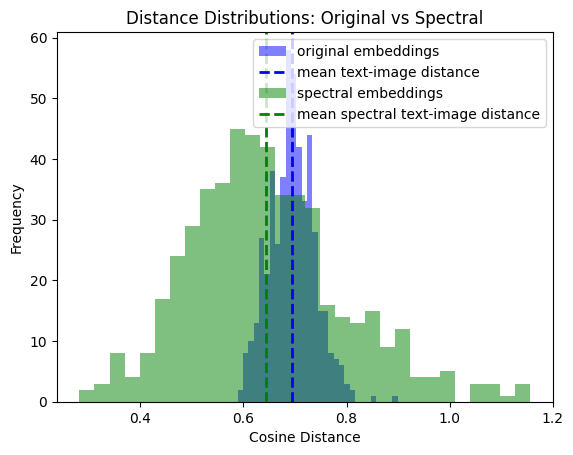

In [246]:
## NOTE: ADD SPECTRAL EMBEDDING DISTANCES
# retrieved from the following paper: https://arxiv.org/pdf/2505.03703
distance=cosine_distances
distances = distance(embeddings, text_embeddings)
gt_distances = np.diag(distances)
global_mean = np.mean(gt_distances)
plt.hist(gt_distances, bins=30, alpha=0.5, label="original embeddings", color='blue')
plt.axvline(global_mean, color='blue', linestyle='dashed', linewidth=2,
        label=f'mean text-image distance')

embeddings_norm = normalize(embeddings, axis=1)
text_embeddings_norm = normalize(text_embeddings, axis=1)

combined = np.vstack([embeddings_norm, text_embeddings_norm])

spectral_combined = compute_spectral_embedding(combined)

spectral_image_embeddings = spectral_combined[:len(embeddings)]
spectral_text_embeddings = spectral_combined[len(embeddings):]

spectral_distances = cosine_distances(spectral_image_embeddings, spectral_text_embeddings)
spectral_gt_distances = np.diag(spectral_distances)
spectral_global_mean = np.mean(spectral_gt_distances)

plt.hist(spectral_gt_distances, bins=30, alpha=0.5, label="spectral embeddings", color='green')
plt.axvline(spectral_global_mean, color='green', linestyle='dashed', linewidth=2,
            label=f'mean spectral text-image distance')
plt.legend()
plt.title("Distance Distributions: Original vs Spectral")
plt.xlabel("Cosine Distance")
plt.ylabel("Frequency")
plt.show()

#A higher mean cosine distance in spectral embeddings isn’t necessarily a problem
# it’s often a sign the embedding is emphasizing global structure differently and 
# possibly reducing noise or modality gaps in a useful way.

In [247]:
points = []
for idx, vec in zip(ids, spectral_image_embeddings):
    if not isinstance(idx, (int, str)):
        raise ValueError(f"Invalid ID type: {idx} (must be int or str)")
    points.append(PointStruct(id=idx, vector=vec.astype(float).tolist(), payload={}))

client.upsert(
    collection_name="spectral_collection",
    points=points,
)

UpdateResult(operation_id=0, status=<UpdateStatus.COMPLETED: 'completed'>)

In [248]:
avg_mrr_spectral = iterate_ds(
    10, df_s_captions, "mrr", processor, model, "original_caption",
    client, "spectral_collection", device,
    use_spectral=True,
    spectral_text_embeddings=spectral_text_embeddings
)
print(avg_mrr_spectral)

avg_recall_at_5_spectral = iterate_ds(
    5, df_s_captions, "recall@5", processor, model, "original_caption",
    client, "spectral_collection", device,
    use_spectral=True,
    spectral_text_embeddings=spectral_text_embeddings
)
print(avg_recall_at_5_spectral)

avg_recall_at_10_spectral = iterate_ds(
    10, df_s_captions, "recall@10", processor, model, "original_caption",
    client, "spectral_collection", device,
    use_spectral=True,
    spectral_text_embeddings=spectral_text_embeddings
)
print(avg_recall_at_10_spectral)


0.47900563030823534
0.0
0.0


In [249]:
def visualize_embeddings_pca(image_embeddings: np.ndarray, text_embeddings: np.ndarray, dimensions=2):
    """
    Visualizes the distance between image and text embeddings using PCA.

    Args:
        image_embeddings - numpy array: Array of shape (N, D) for image features
        text_embeddings - numpy array: Array of shape (N, D) for text features
        dimensions - int: Number of dimensions for the graph. Can be either 2 or 3
    Returns:
        None
    """

    # stack all the embeddings so we can perform PCA
    combined = np.vstack([image_embeddings, text_embeddings])
    # perform PCA
    pca = PCA(n_components=dimensions)
    reduced = pca.fit_transform(combined)

    # differentiate between image and text embeddings 
    n = image_embeddings.shape[0]
    img_points = reduced[:n]
    txt_points = reduced[n:]

    # draw a 2d graph if dimensions are 2 and if not, we draw a 3D graph
    if dimensions == 2:
        # create a scatter plot
        plt.figure(figsize=(10, 8))
        plt.scatter(img_points[:, 0], img_points[:, 1], c='blue', label='Images', alpha=0.6)
        plt.scatter(txt_points[:, 0], txt_points[:, 1], c='red', label='Captions', alpha=0.6)

        # draw lines to visualise between each embedding
        for i in range(n):
            plt.plot([img_points[i, 0], txt_points[i, 0]],
                    [img_points[i, 1], txt_points[i, 1]],
                    c='gray', linestyle='--', linewidth=0.5)
            plt.xlabel("PCA 1")
            plt.ylabel("PCA 2")
    elif dimensions == 3:
        fig = plt.figure(figsize=(12, 9))
        ax = fig.add_subplot(111, projection='3d')

        # Scatter plot
        ax.scatter(img_points[:, 0], img_points[:, 1], img_points[:, 2], c='blue', label='Images', alpha=0.7)
        ax.scatter(txt_points[:, 0], txt_points[:, 1], txt_points[:, 2], c='red', label='Captions', alpha=0.7)

        # Draw lines between matching pairs
        for i in range(n):
            ax.plot(
                [img_points[i, 0], txt_points[i, 0]],
                [img_points[i, 1], txt_points[i, 1]],
                [img_points[i, 2], txt_points[i, 2]],
                c='gray', linestyle='--', linewidth=0.5
            )
        ax.set_ylabel("PCA 2")
        ax.set_xlabel("PCA 1")
        ax.set_zlabel("PCA 3")
        

    plt.title("PCA Visualization of Image and Text Embeddings")
    plt.legend()
    plt.grid(True)
    plt.show()

In [250]:
# convert outer list which stores numpy arrays into a numpy array
img_embeddings_np = np.stack(embeddings)
text_embeddings_np = np.stack(text_embeddings)

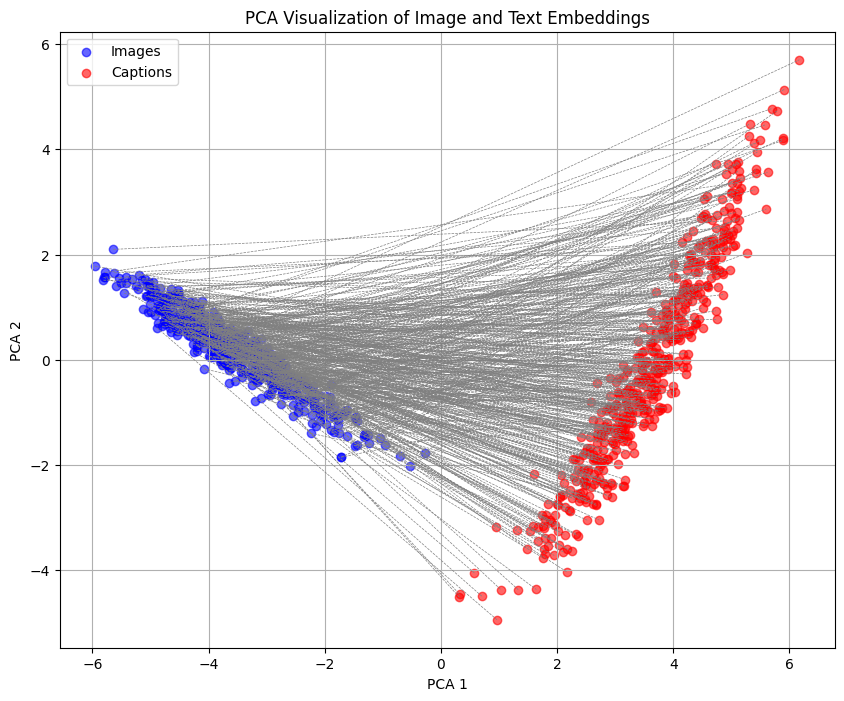

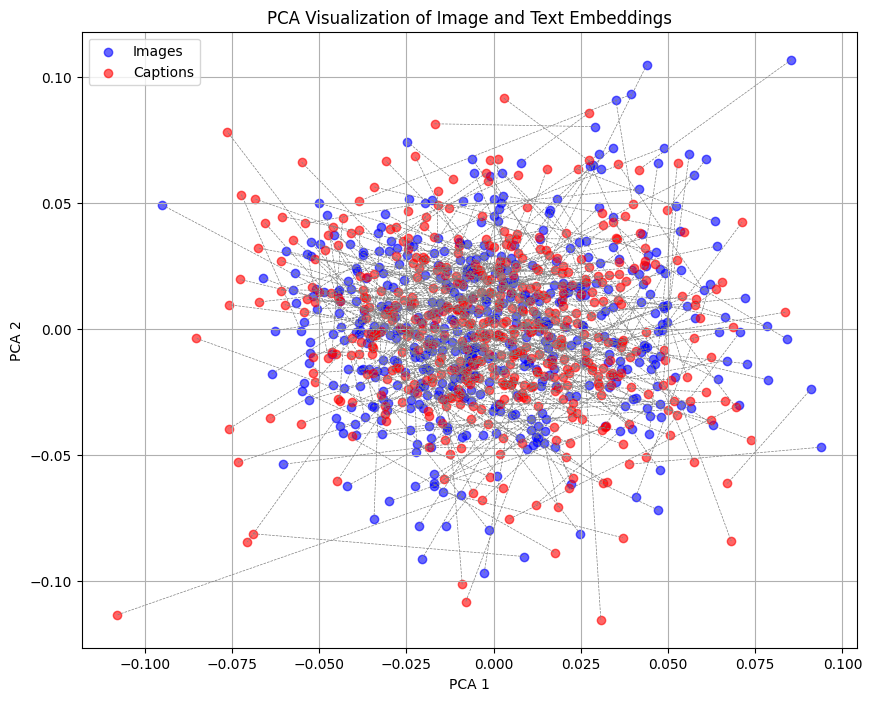

In [251]:
visualize_embeddings_pca(img_embeddings_np, text_embeddings_np, 2)
visualize_embeddings_pca(spectral_image_embeddings, spectral_text_embeddings, 2)

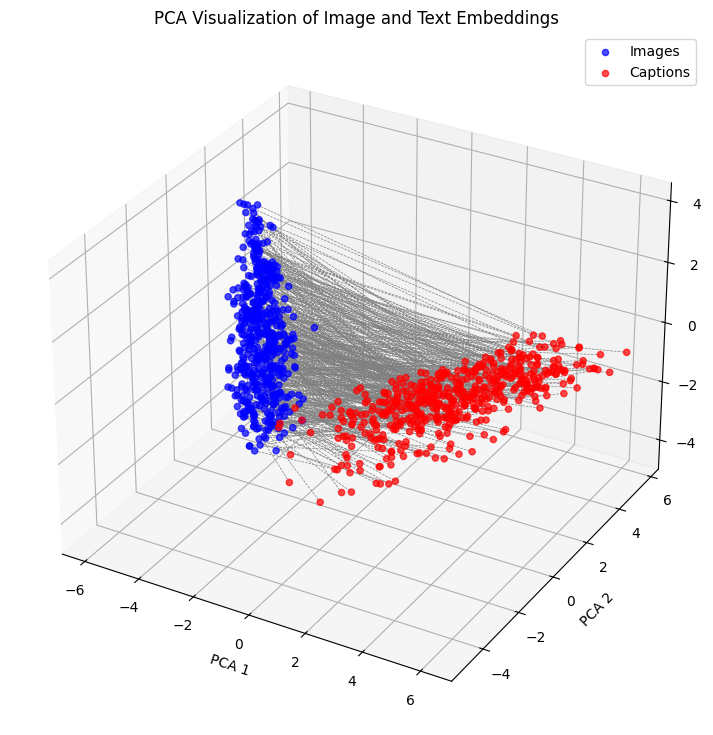

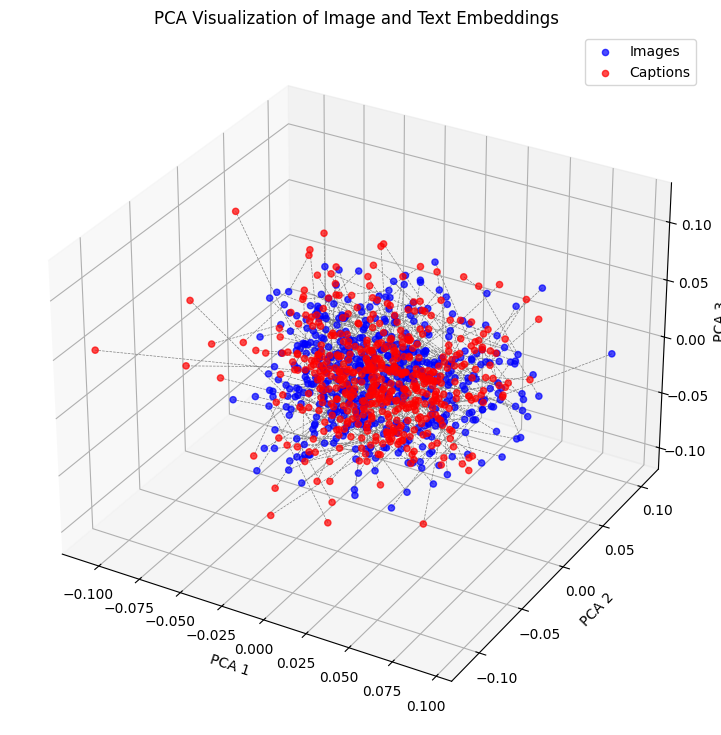

In [252]:
visualize_embeddings_pca(img_embeddings_np, text_embeddings_np, 3)
visualize_embeddings_pca(spectral_image_embeddings, spectral_text_embeddings, 3)